# STAGE 14 — CONSERVATIVE ADAPTIVE SELECTION

Цель — проверить три заранее заданные консервативные policy. Forecasting models не переобучаются, threshold grid не строится, production winner автоматически не выбирается. Lower rate = better.

Обязательный invariant `favourability_percentile_20 >= 0.70` имеет приоритет над локальным floor `0.65` у POLICY_C. Поэтому эффективный floor C равен 0.70; при прочих одинаковых параметрах B и C должны совпасть.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists(): ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.conservative_adaptive_selection import run_conservative_adaptive
result = run_conservative_adaptive(ROOT, make_plots=True)
print('History rows:', len(result['full']))
print('Locked-test rows:', len(result['test']))
print('Forecasting retraining: NO')

History rows: 2745
Locked-test rows: 1375
Forecasting retraining: NO


## Метод

`regret_quality = clip(1 - predicted_regret_5 / 0.010, 0, 1)`, а `good_day_score = 0.60 × favourability + 0.40 × regret_quality`. `past_advantage_5` сохранен только как диагностика. Сначала проверяется absolute eligibility, затем по строго предыдущим 20 scores вычисляется adaptive percentile 80% / 70% / 60%, после чего применяется cooldown в три quote observations. Actual regret участвует только в ground truth.

In [2]:
summary_columns = ['corridor','policy','n_signals','median_signals_per_month','months_with_zero_signals','max_gap_quote_observations','hit_rate','uplift','min_favourability_at_signal','max_predicted_regret_at_signal']
display(result['results'][summary_columns])
display(Markdown('## Mandatory invariant checks'))
display(result['invariants'])
display(Markdown('## Leakage checks'))
display(result['leakage'])

,corridor,policy,n_signals,median_signals_per_month,months_with_zero_signals,max_gap_quote_observations,hit_rate,uplift,min_favourability_at_signal,max_predicted_regret_at_signal
0,AMD_RUB,POLICY_A_STRICT,16,0.0,8,45,0.250000,2.590674,0.75,0.002262
1,AMD_RUB,POLICY_B_BALANCED,16,0.0,8,45,0.250000,2.590674,0.75,0.002262
2,AMD_RUB,POLICY_C_MORE_FREQUENT,16,0.0,8,45,0.250000,2.590674,0.75,0.002262
3,KGS_RUB,POLICY_A_STRICT,19,0.5,7,27,0.263158,2.793296,0.75,0.002184
4,KGS_RUB,POLICY_B_BALANCED,19,0.5,7,26,0.263158,2.793296,0.70,0.002184
5,KGS_RUB,POLICY_C_MORE_FREQUENT,19,0.5,7,26,0.263158,2.793296,0.70,0.002184
6,KZT_RUB,POLICY_A_STRICT,19,1.5,6,48,0.421053,4.073320,0.75,0.003397
7,KZT_RUB,POLICY_B_BALANCED,19,1.5,6,47,0.315789,3.054990,0.70,0.003397
8,KZT_RUB,POLICY_C_MORE_FREQUENT,19,1.5,6,47,0.315789,3.054990,0.70,0.003397
9,TJS_RUB,POLICY_A_STRICT,23,2.0,6,26,0.347826,2.976190,0.75,0.001810


## Mandatory invariant checks

,policy,check,violations,passed
0,POLICY_A_STRICT,signal_with_favourability_below_0_70,0,True
1,POLICY_A_STRICT,signal_with_predicted_regret_above_1pct,0,True
2,POLICY_A_STRICT,signal_with_favourability_below_0_50,0,True
3,POLICY_B_BALANCED,signal_with_favourability_below_0_70,0,True
4,POLICY_B_BALANCED,signal_with_predicted_regret_above_1pct,0,True
5,POLICY_B_BALANCED,signal_with_favourability_below_0_50,0,True
6,POLICY_C_MORE_FREQUENT,signal_with_favourability_below_0_70,0,True
7,POLICY_C_MORE_FREQUENT,signal_with_predicted_regret_above_1pct,0,True
8,POLICY_C_MORE_FREQUENT,signal_with_favourability_below_0_50,0,True


## Leakage checks

,check,passed
0,rolling thresholds use history strictly before T,True
1,current T excluded,True
2,no full-period normalization,True
3,actual_regret used only for evaluation,True
4,eligibility uses only causal features,True
5,observations_since_last_signal is causal,True
6,cooldown is causal,True
7,processing separate by corridor and policy,True


## Визуальная проверка сигналов

Красные точки обозначают сигналы. Для каждого коридора сначала показаны три policy на одинаковых осях, затем отдельная проверка POLICY_B вместе с favourability и уровнями 0.70/0.85.

### AMD_RUB: три policy

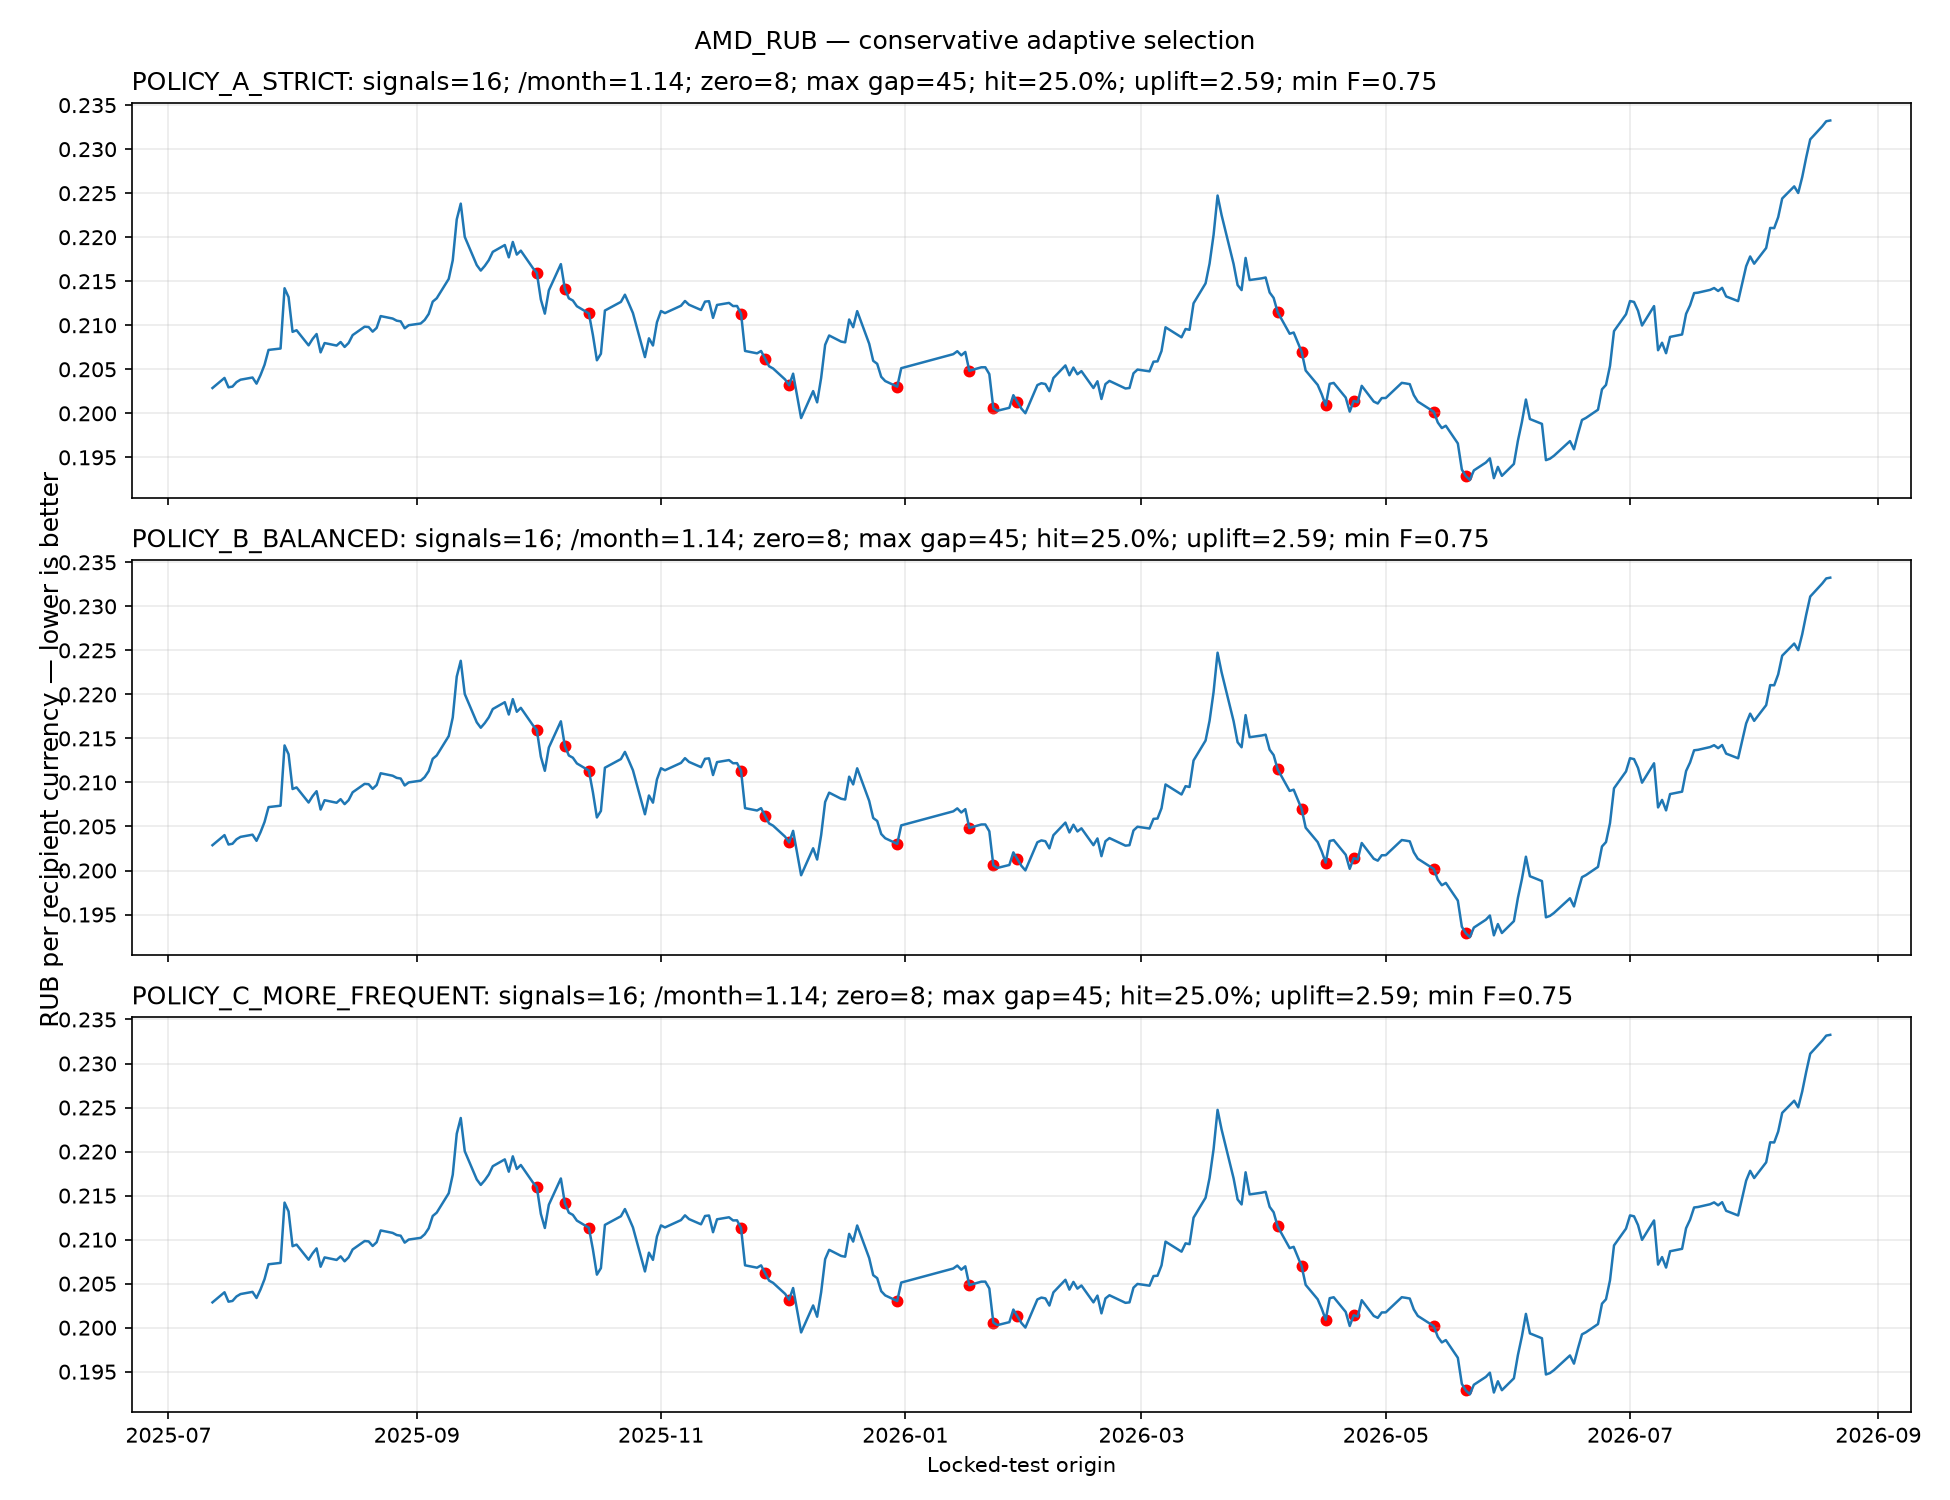

### AMD_RUB: качество сигналов POLICY_B_BALANCED

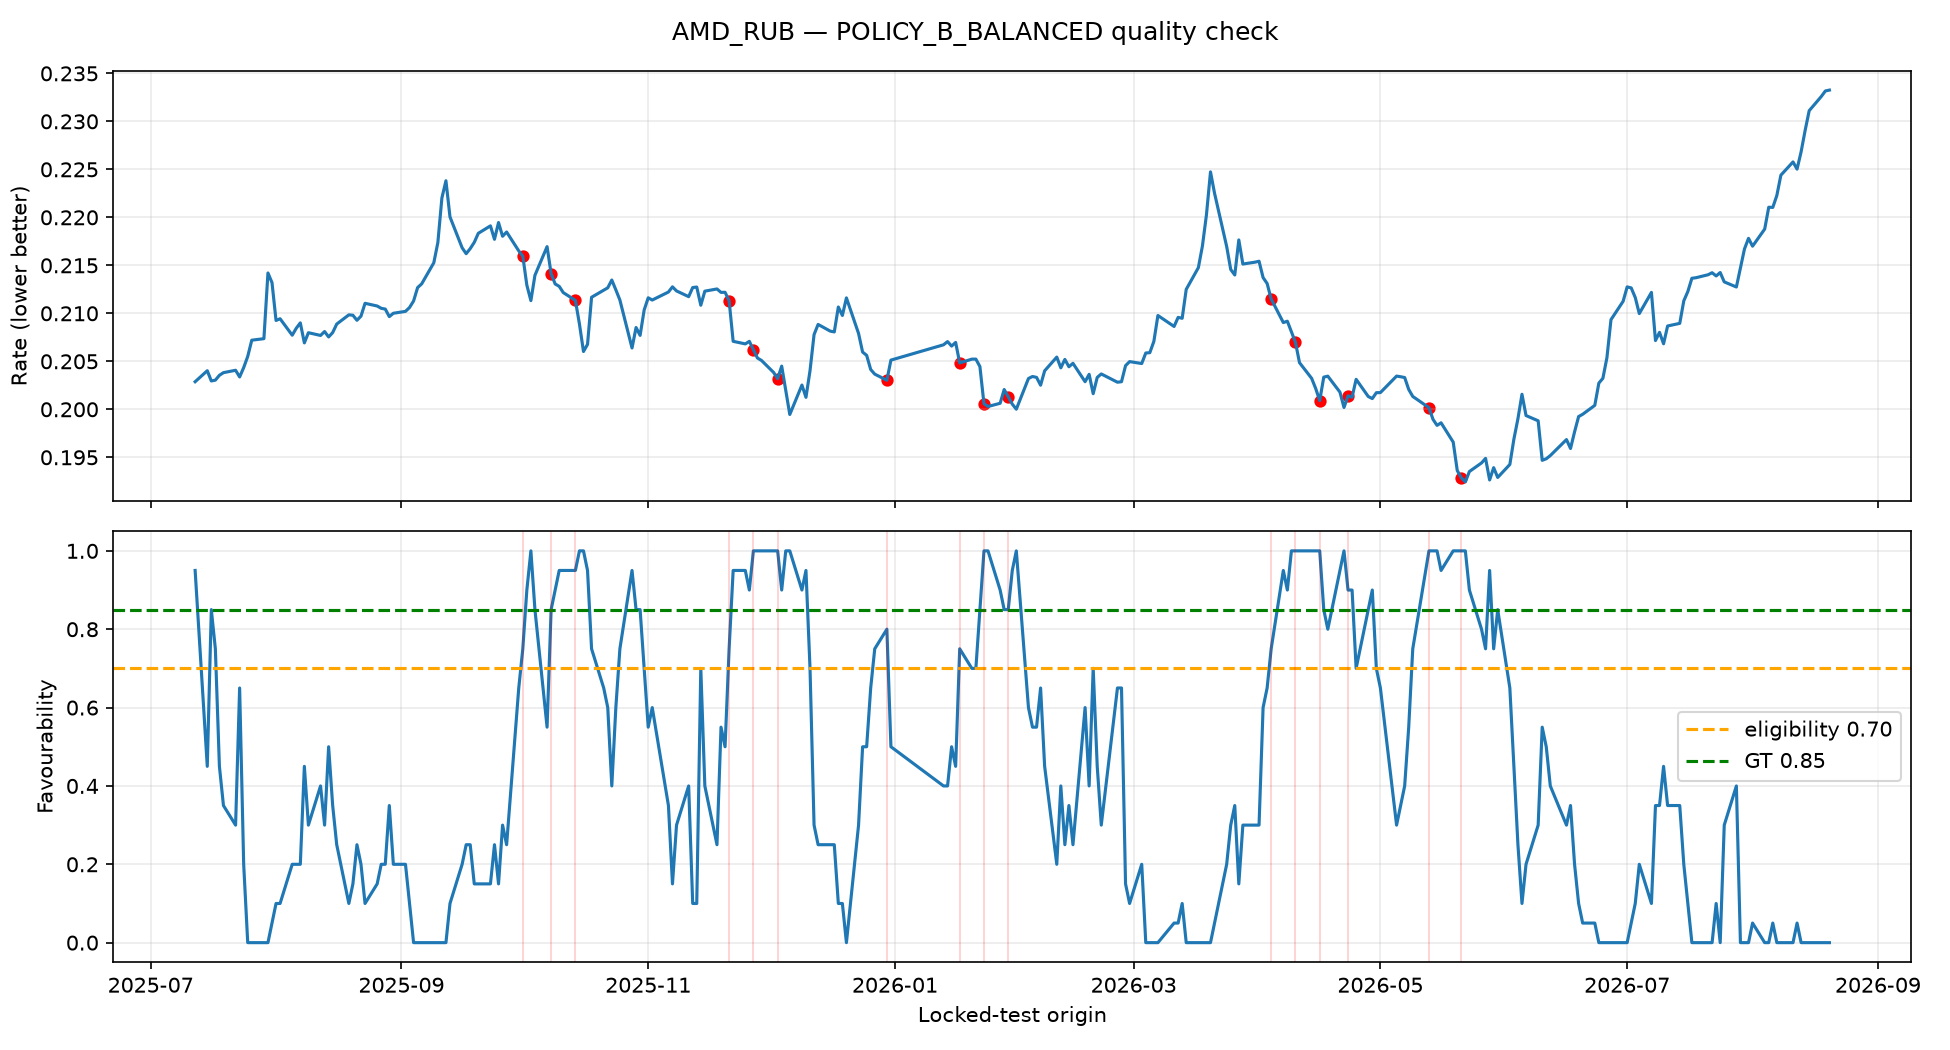

### KGS_RUB: три policy

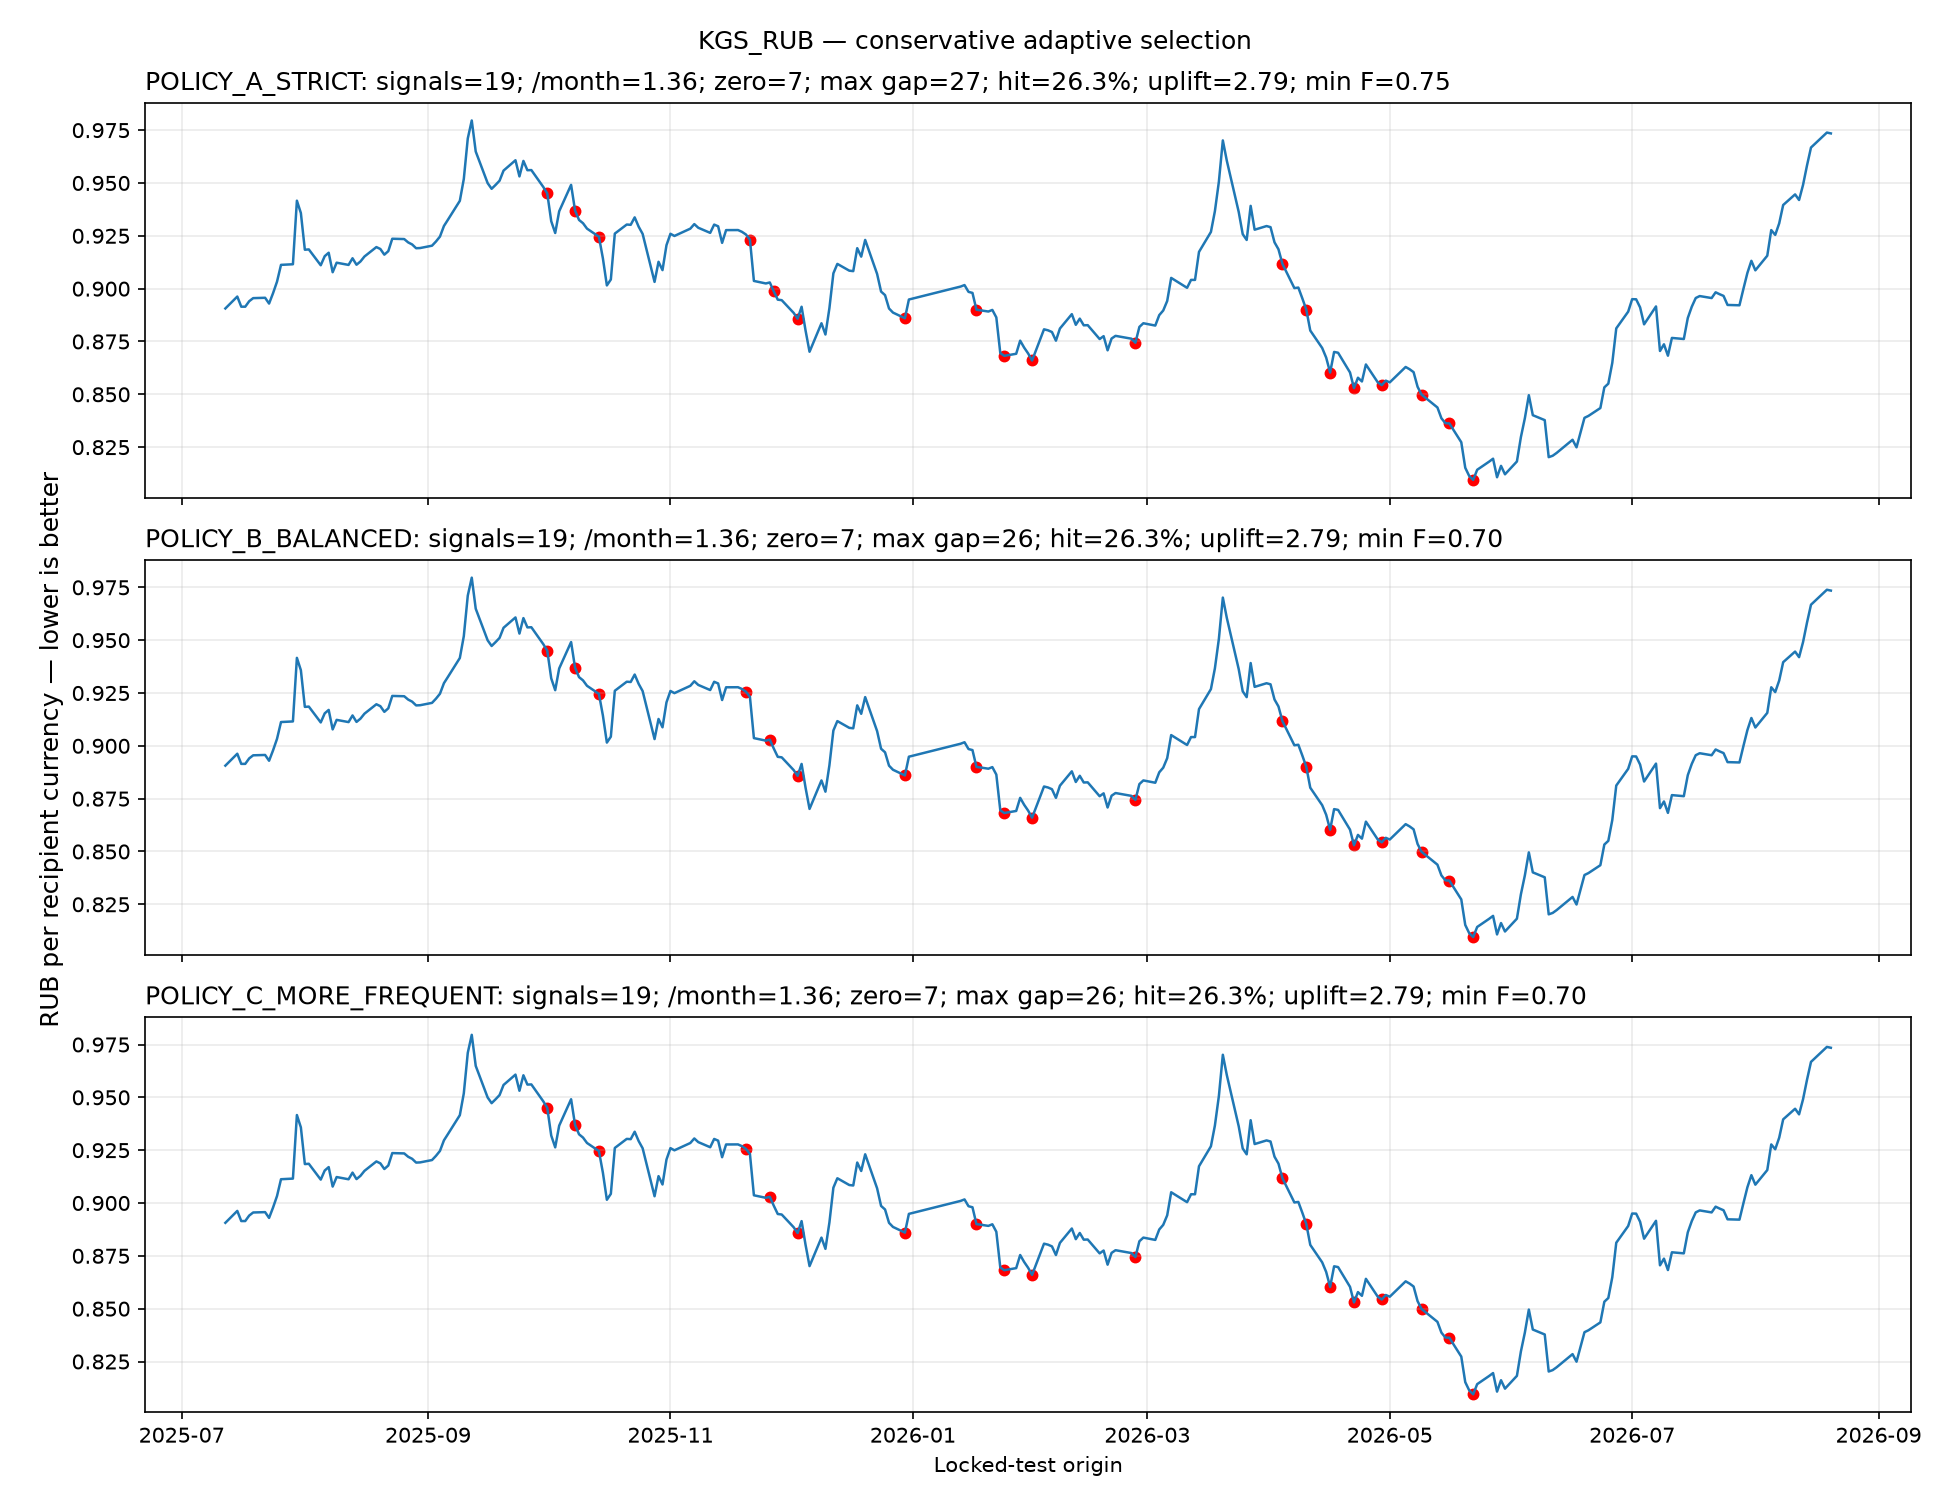

### KGS_RUB: качество сигналов POLICY_B_BALANCED

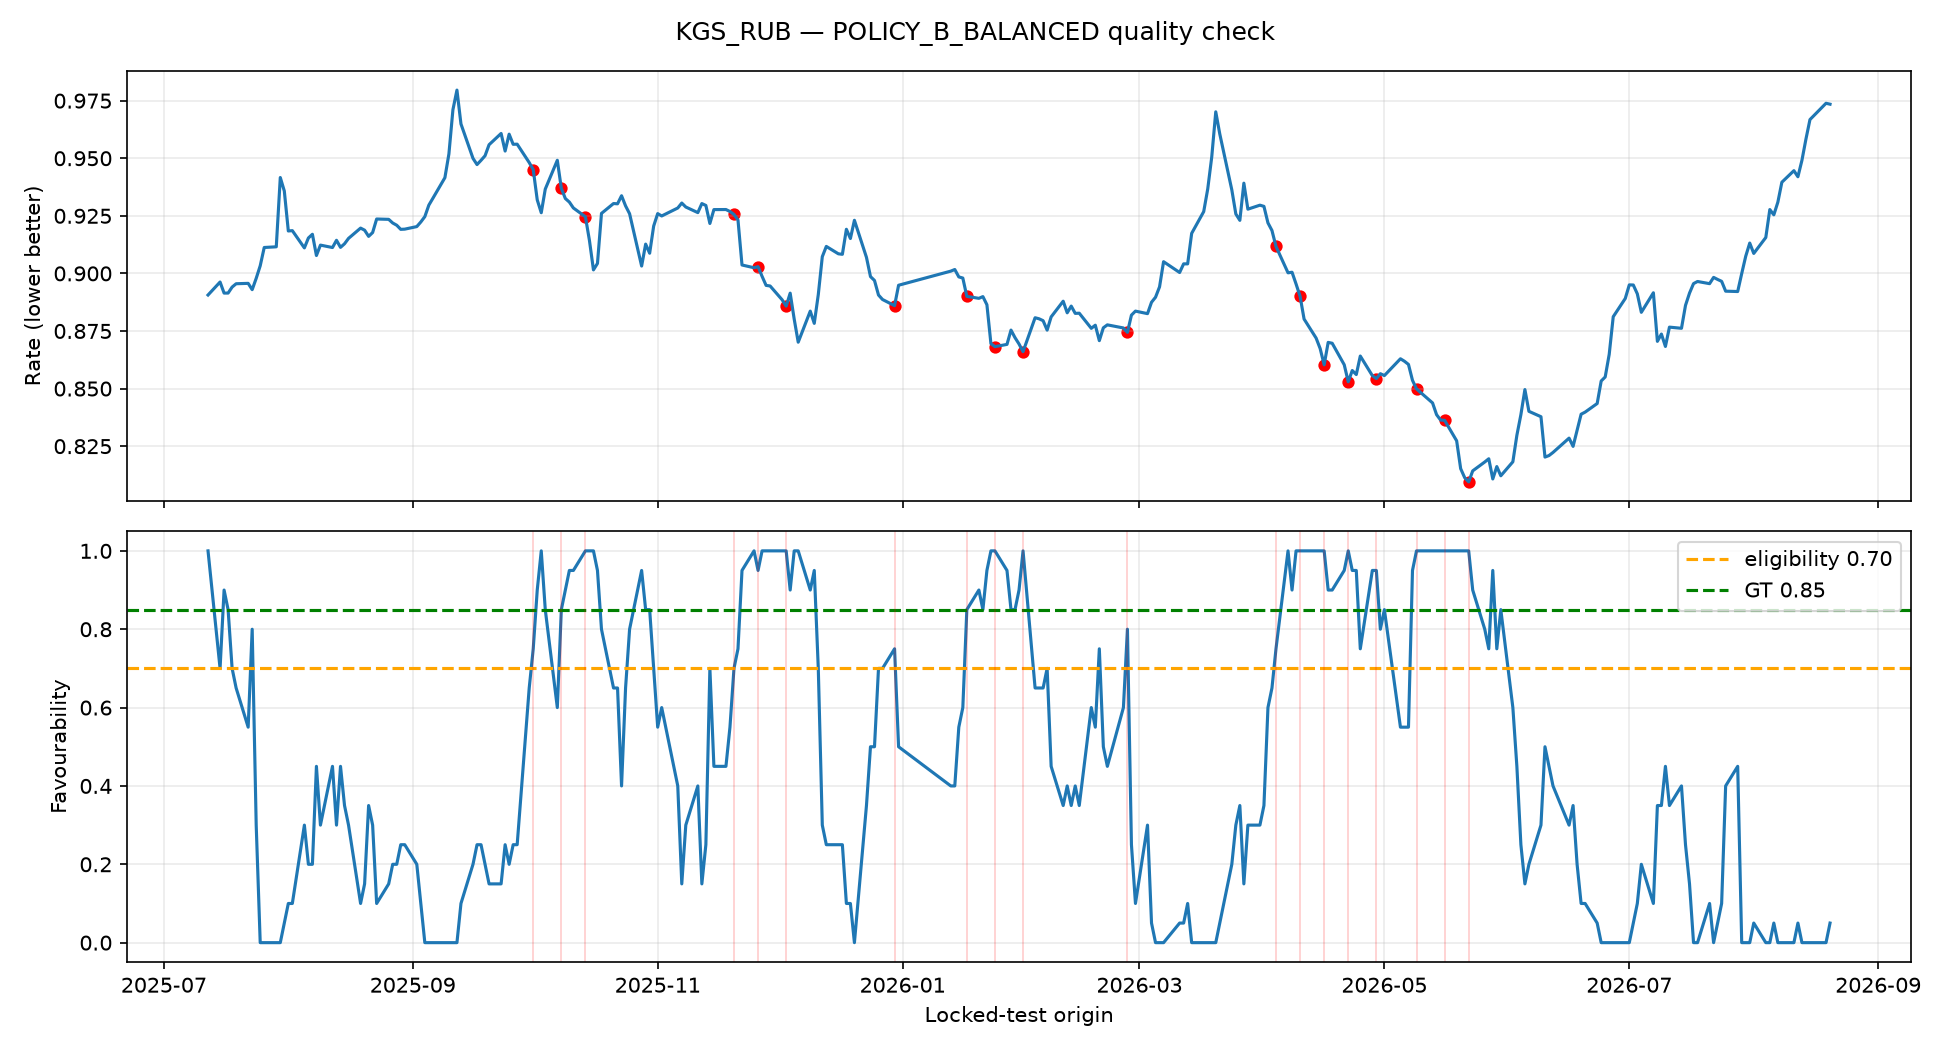

### KZT_RUB: три policy

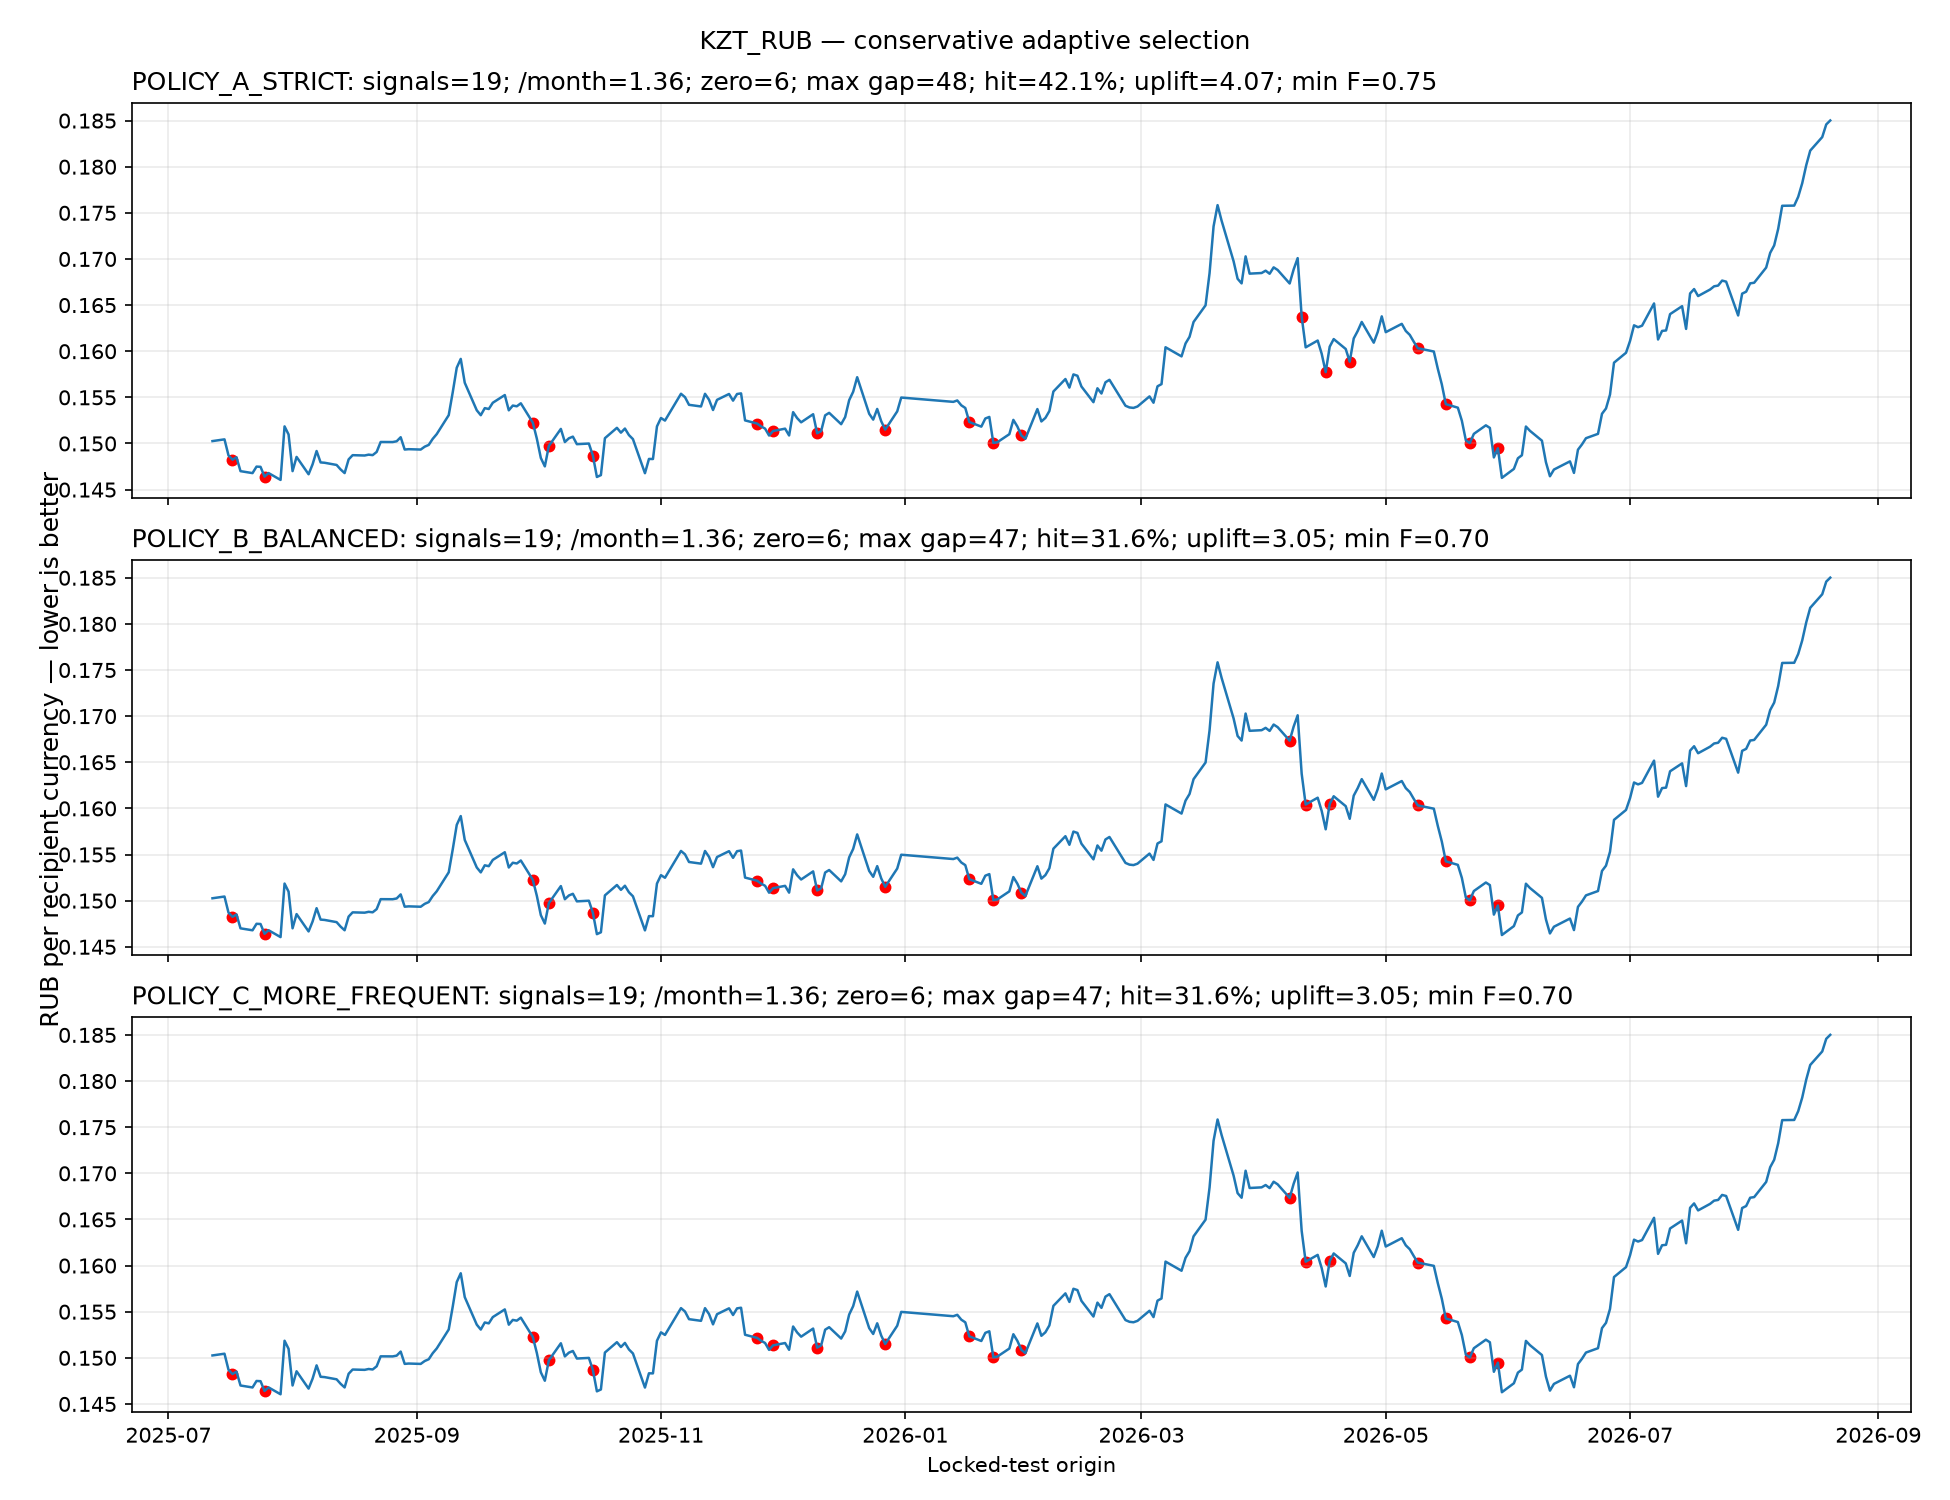

### KZT_RUB: качество сигналов POLICY_B_BALANCED

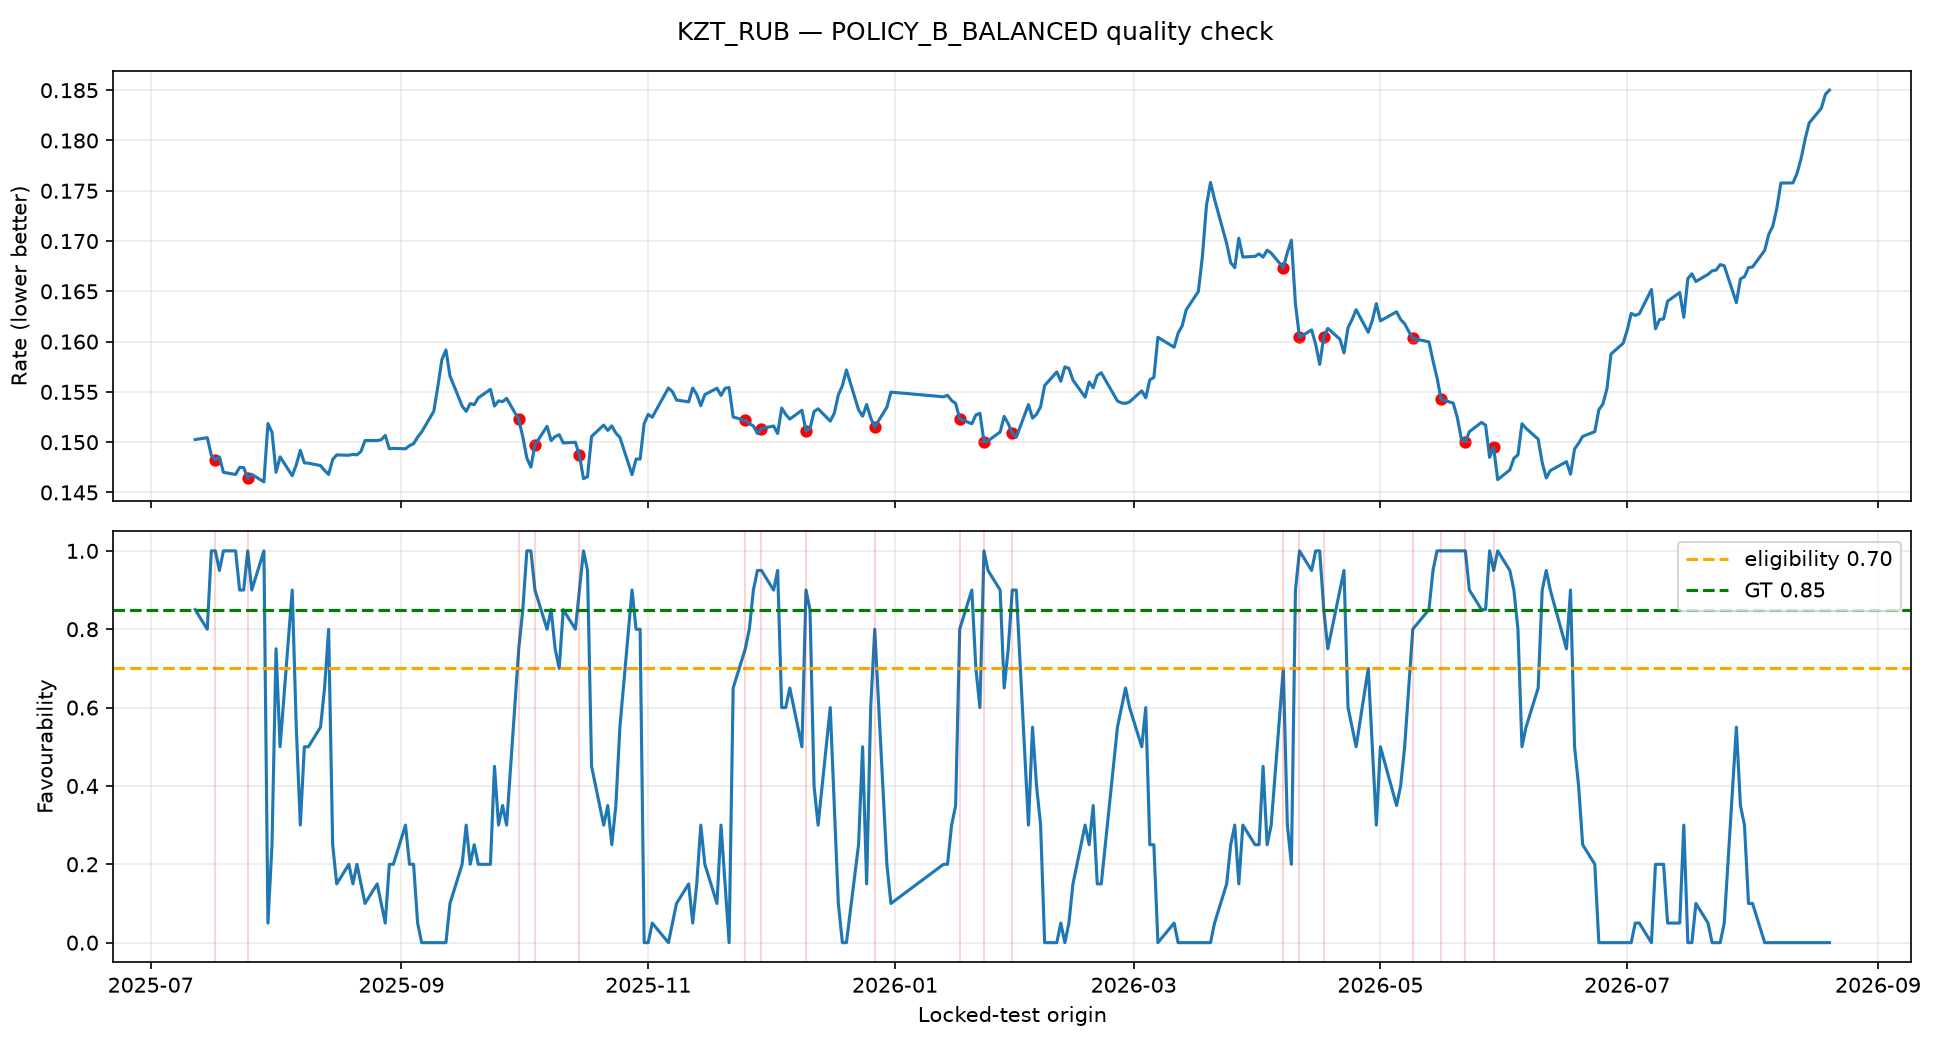

### TJS_RUB: три policy

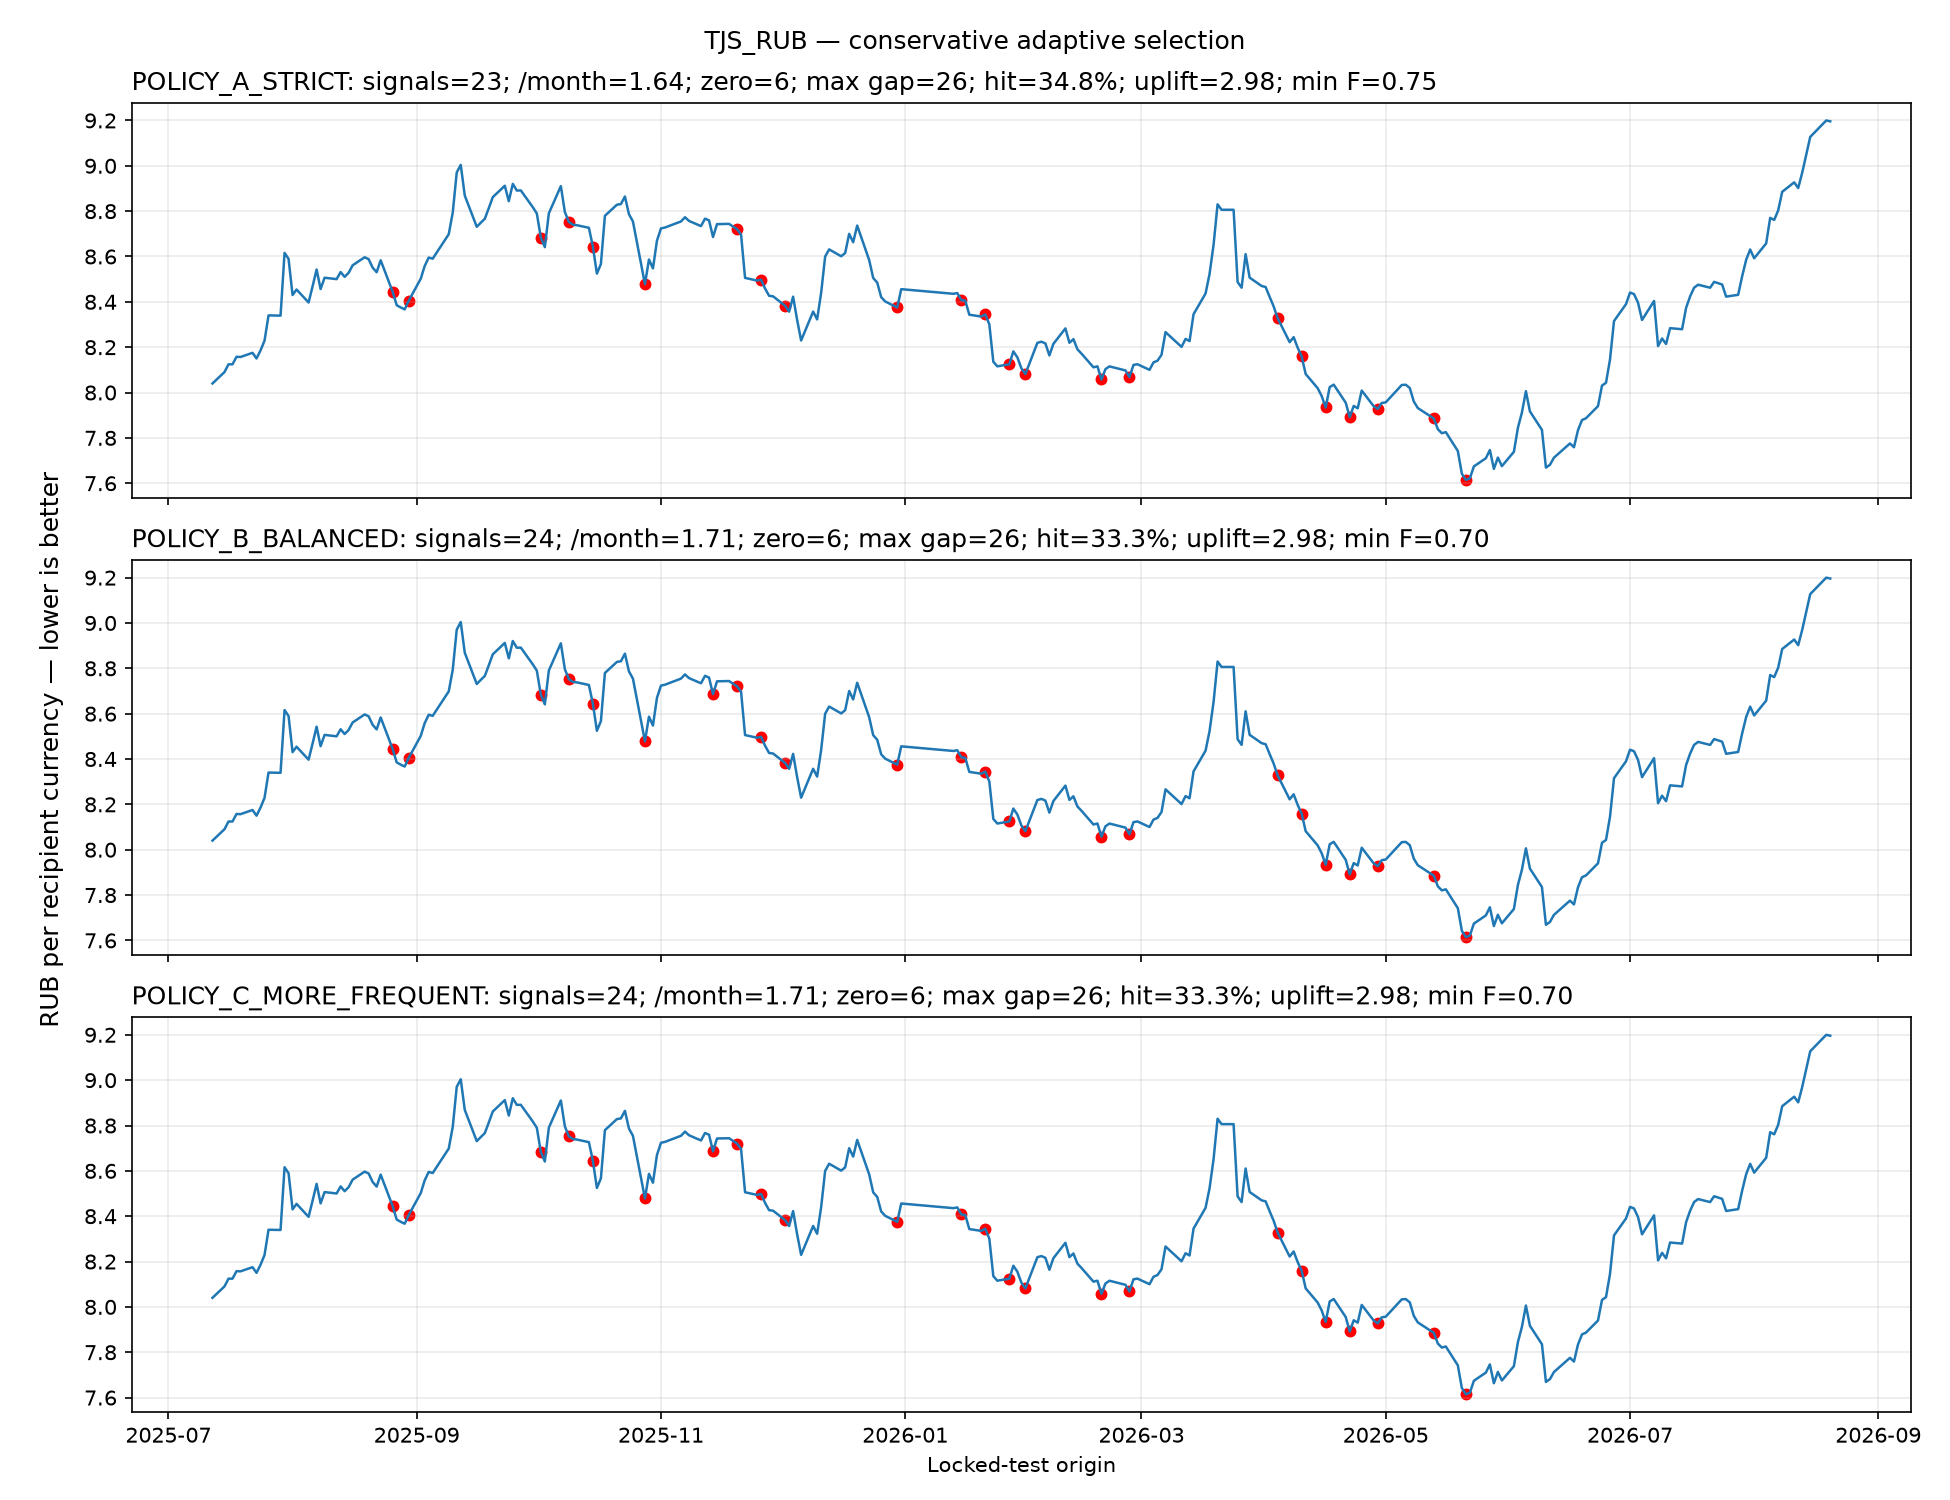

### TJS_RUB: качество сигналов POLICY_B_BALANCED

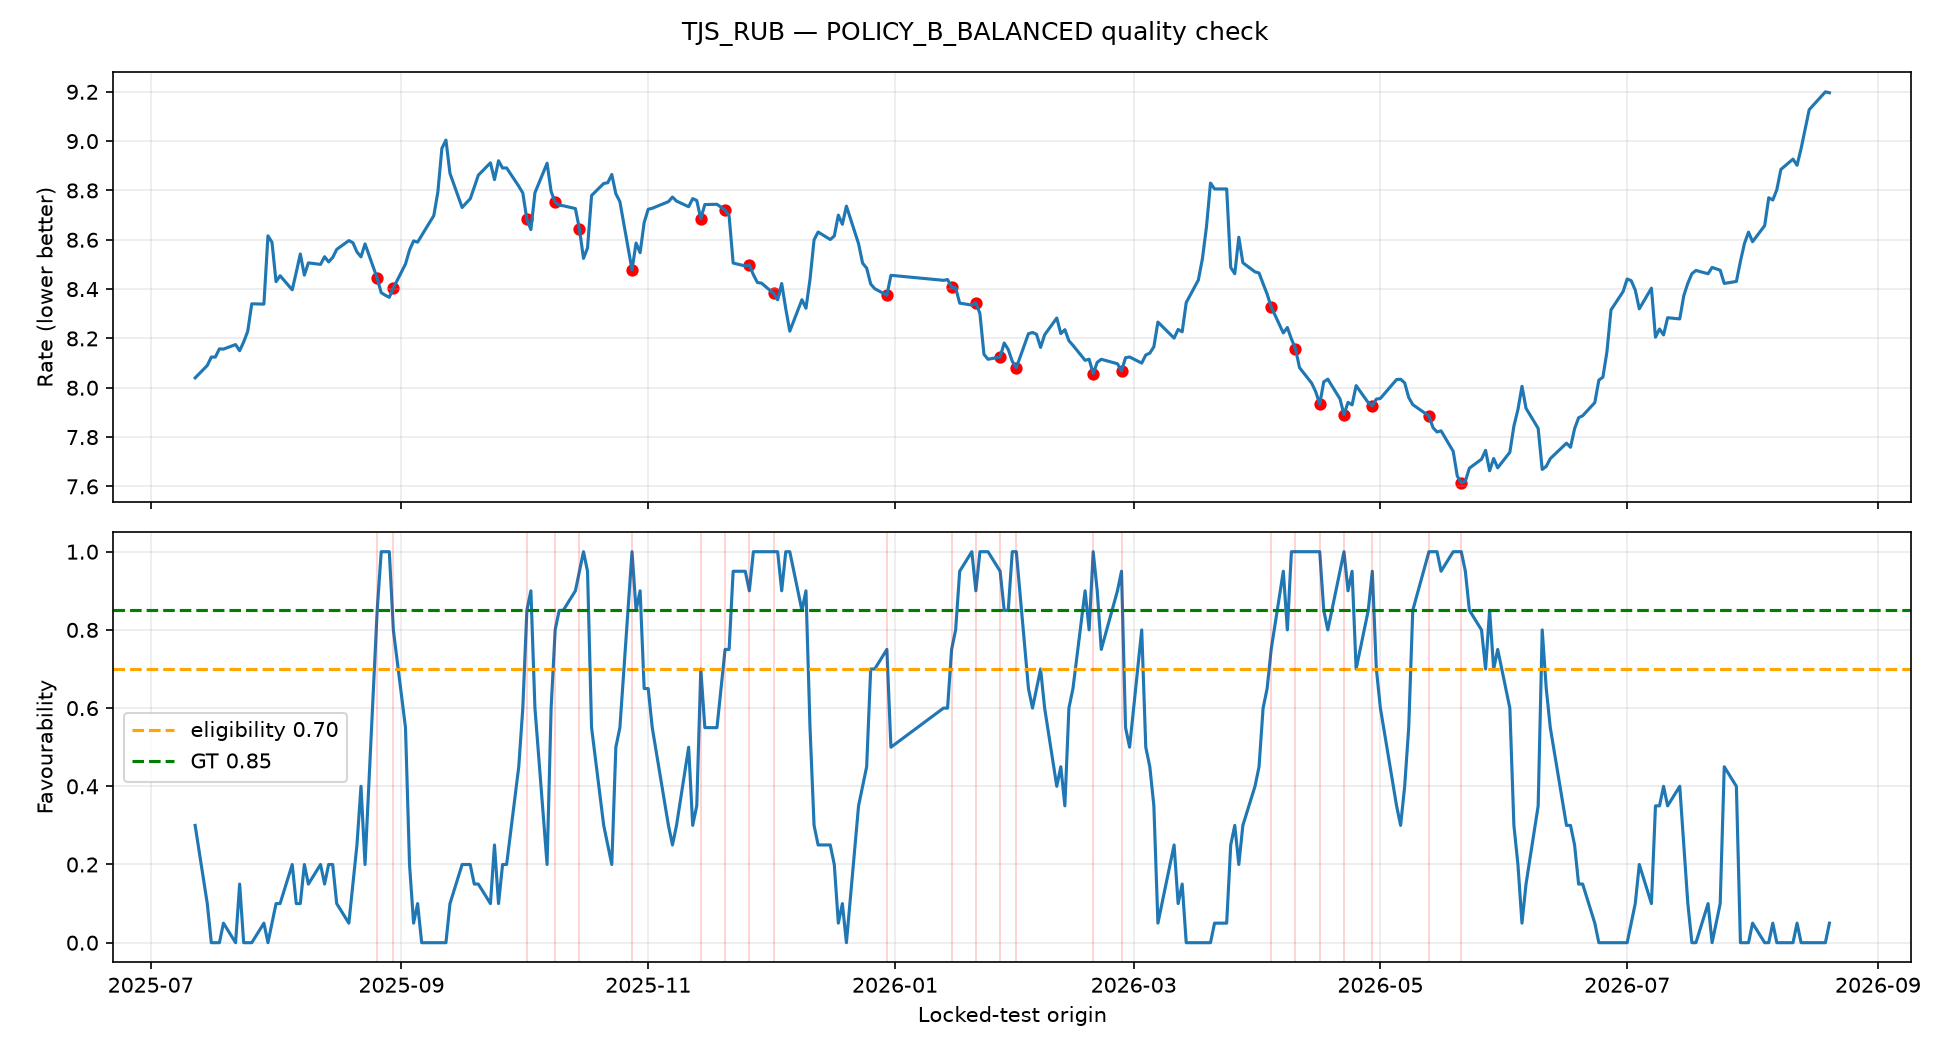

### UZS_RUB: три policy

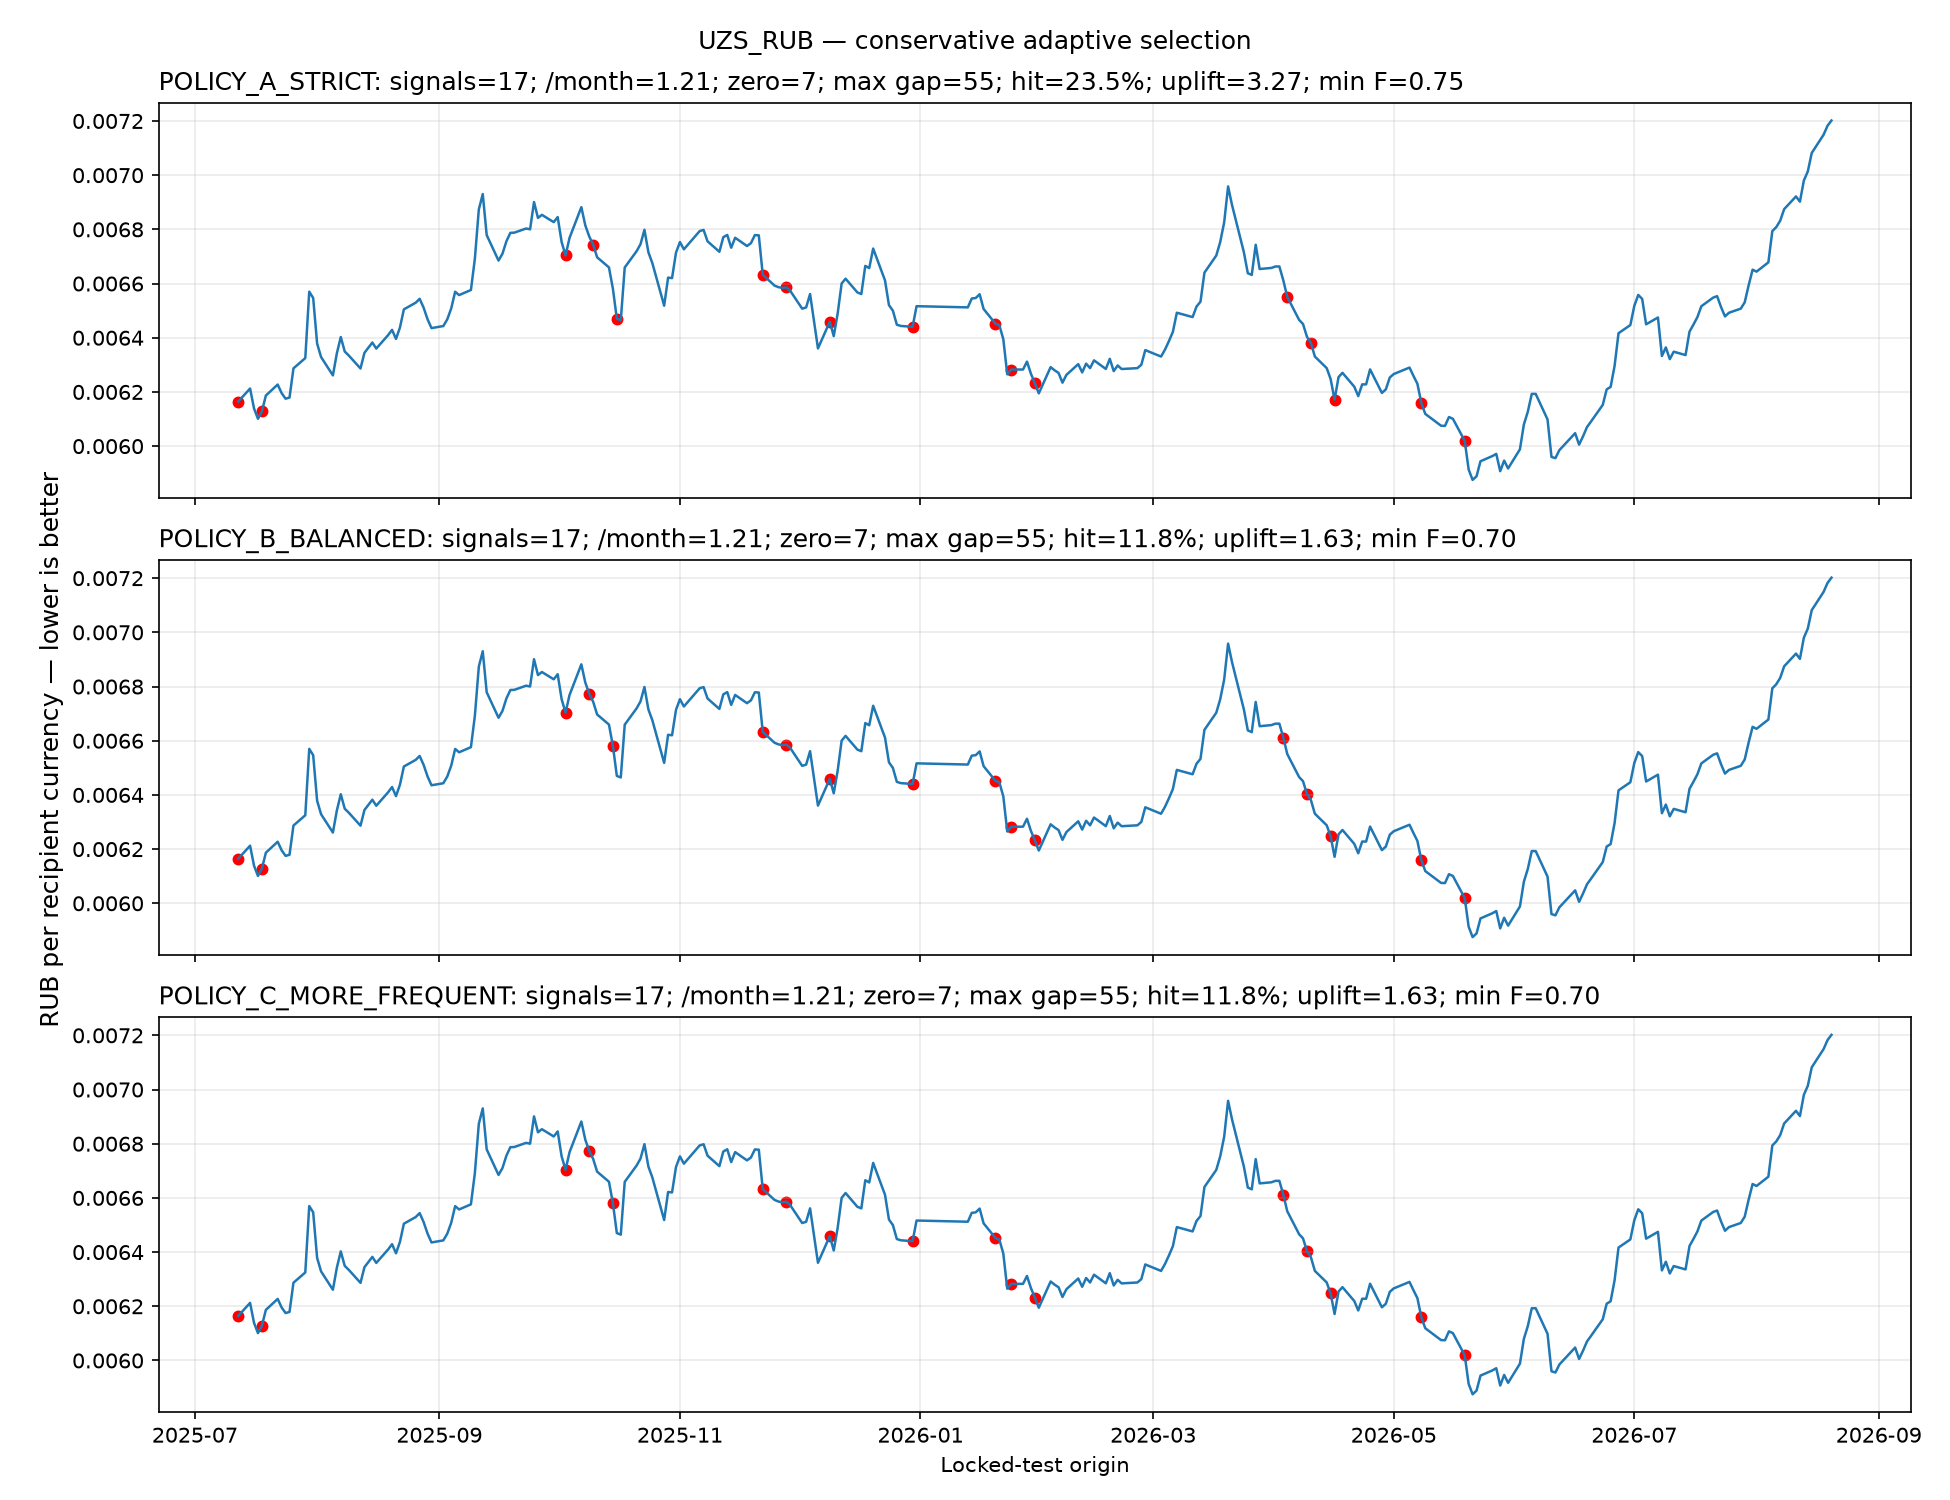

### UZS_RUB: качество сигналов POLICY_B_BALANCED

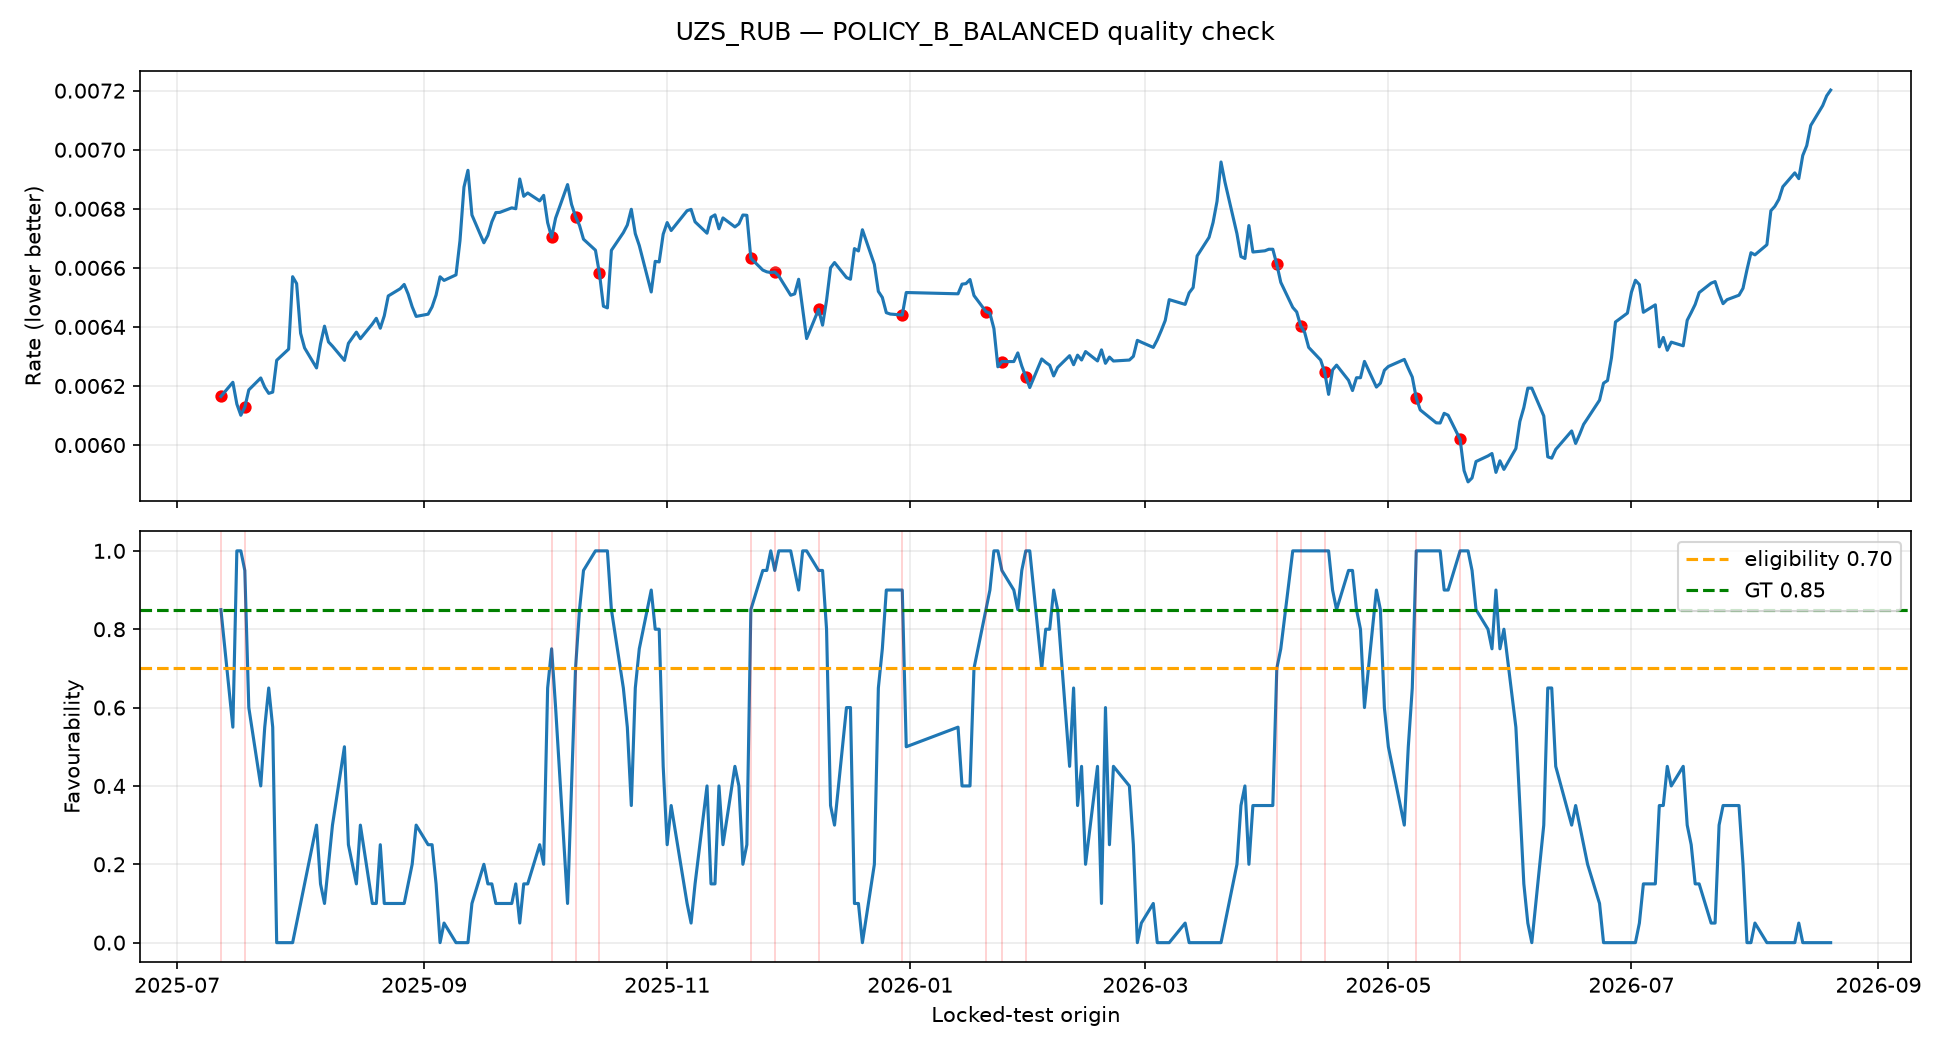

### AMD_RUB: score и adaptive threshold

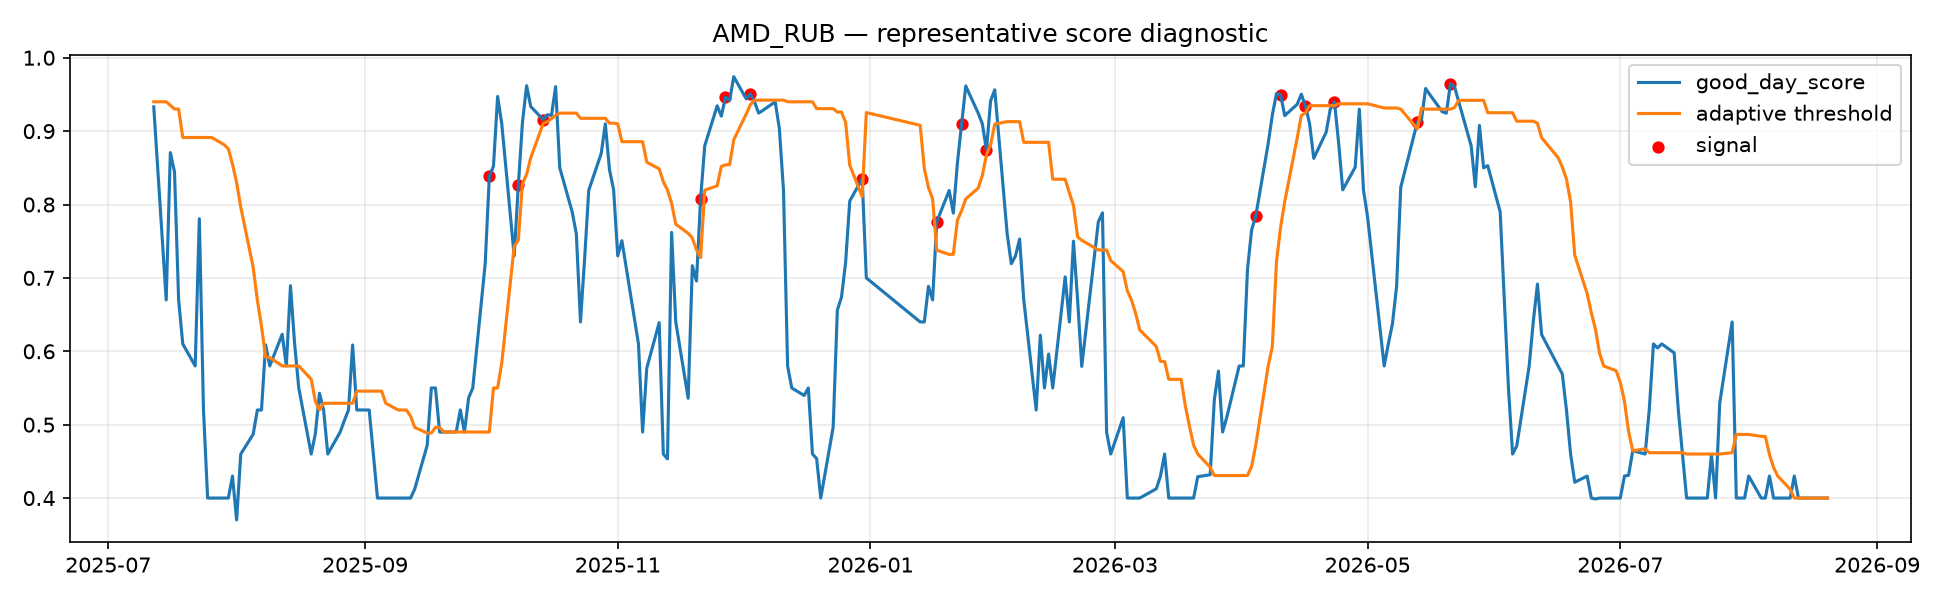

In [3]:
FIGURE_DIR = ROOT / 'reports' / 'figures' / 'conservative_adaptive'
for corridor in sorted(result['test']['corridor'].unique()):
    display(Markdown(f'### {corridor}: три policy'))
    display(Image(filename=str(FIGURE_DIR / f'{corridor}_three_policies.png')))
    display(Markdown(f'### {corridor}: качество сигналов POLICY_B_BALANCED'))
    display(Image(filename=str(FIGURE_DIR / f'{corridor}_balanced_quality.png')))
representative = sorted(result['test']['corridor'].unique())[0]
display(Markdown(f'### {representative}: score и adaptive threshold'))
display(Image(filename=str(FIGURE_DIR / f'{representative}_score_threshold.png')))

## Интерпретация

Основной trade-off читается совместно: frequency/gaps показывают доступность сигнала, а hit rate, uplift, regret и минимальная favourability — его качество. Этот этап отвечает, удается ли уменьшить длинные периоды тишины, не пропуская объективно плохие уровни; он не назначает лучшую production-policy.

In [4]:
display(result['monthly'].head(20))
invariants_pass = result['invariants']['passed'].all()
leakage_pass = result['leakage']['passed'].all()
print('CONSERVATIVE ADAPTIVE INVARIANTS:', 'PASS' if invariants_pass else 'FAIL')
print('CONSERVATIVE ADAPTIVE LEAKAGE CHECK:', 'PASS' if leakage_pass else 'FAIL')
print('STAGE 14 — CONSERVATIVE ADAPTIVE SELECTION:', 'PASS' if invariants_pass and leakage_pass else 'FAIL')

,corridor,policy,month,n_signals,n_hits,mean_favourability_signal,hit_rate
0,AMD_RUB,POLICY_A_STRICT,2025-07,0,0,NaN,NaN
1,AMD_RUB,POLICY_A_STRICT,2025-08,0,0,NaN,NaN
2,AMD_RUB,POLICY_A_STRICT,2025-09,0,0,NaN,NaN
3,AMD_RUB,POLICY_A_STRICT,2025-10,3,0,0.850000,0.000000
4,AMD_RUB,POLICY_A_STRICT,2025-11,2,0,0.875000,0.000000
5,AMD_RUB,POLICY_A_STRICT,2025-12,2,0,0.900000,0.000000
6,AMD_RUB,POLICY_A_STRICT,2026-01,3,1,0.866667,0.333333
7,AMD_RUB,POLICY_A_STRICT,2026-02,0,0,NaN,NaN
8,AMD_RUB,POLICY_A_STRICT,2026-03,0,0,NaN,NaN
9,AMD_RUB,POLICY_A_STRICT,2026-04,4,2,0.912500,0.500000


CONSERVATIVE ADAPTIVE INVARIANTS: PASS
CONSERVATIVE ADAPTIVE LEAKAGE CHECK: PASS
STAGE 14 — CONSERVATIVE ADAPTIVE SELECTION: PASS
